In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

In [2]:
PRIMARY = '#2980B9'   # Xanh (main - customers)
SECONDARY = '#F39C12' # Cam (revenue)
                      # RdYlGn (Đỏ-Vàng-Xanh lá)
plt.rcParams['axes.grid'] = False

In [3]:
df = pd.read_excel('ecommerce retail.xlsx')

In [4]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


I/ DATA CLEANING

In [5]:
df_clean = df.copy()

In [6]:
df_clean = df_clean.drop_duplicates()

In [7]:
df_clean= df_clean[pd.notnull(df_clean['CustomerID'])]

In [8]:
# Correcting datatype
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

In [9]:
#Removing InvoiceNo prefix C: Cancel
df_clean =  df_clean[~ df_clean['InvoiceNo'].str.startswith('C', na=False)]

In [10]:
#Removing Quantity <=0, Unit Price <=0
df_clean= df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

In [11]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  int64         
 7   Country      392692 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 27.0+ MB


In [12]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,392692.000000,392692,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000
std,180.492832,NaN,22.241836,1713.539549


In [13]:
print(f"Raw data: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"After cleaning: {df_clean.shape[0]:,} rows ({df_clean.shape[0]/df.shape[0]*100:.1f}% retained)")
print(f"Unique customers: {df_clean['CustomerID'].nunique():,}")
print(f"Date range: {df_clean['InvoiceDate'].min().date()} → {df_clean['InvoiceDate'].max().date()}")

Raw data: 541,909 rows × 8 columns
After cleaning: 392,692 rows (72.5% retained)
Unique customers: 4,338
Date range: 2010-12-01 → 2011-12-09


In [14]:
df_clean

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France


In [15]:
# Revenue each InvoiceNo
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

II/ EDA

In [16]:
# Cnt Customers (DISTINCT Customer ID)
print(f"Total number of customers: {df_clean['CustomerID'].nunique()}")

Total number of customers: 4338


<Axes: xlabel='Country'>

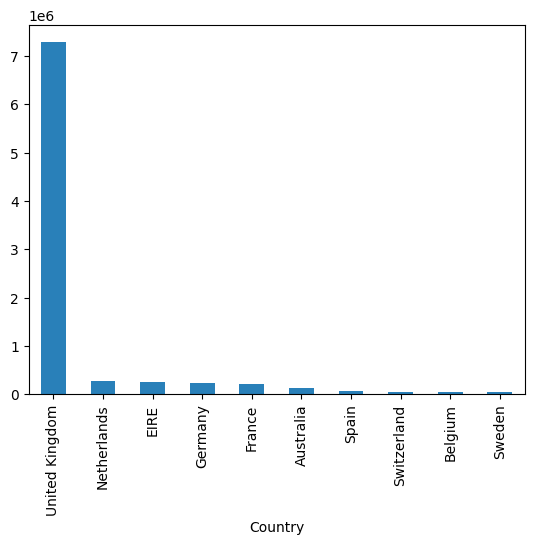

In [17]:
# Tính tổng doanh thu cho từng country
top_10_rev_country = df_clean.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

top_10_rev_country.plot(kind='bar', color=PRIMARY)


<Axes: ylabel='Description'>

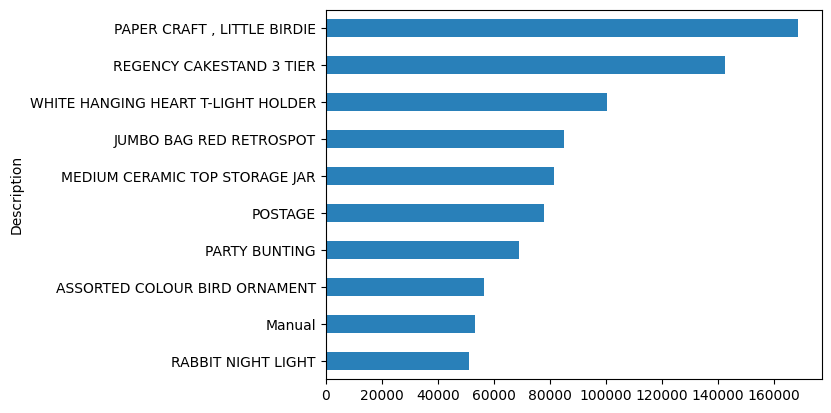

In [18]:
# Tính tổng doanh thu cho từng sản phẩm
top_10_rev_product = df_clean.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

# Vẽ biểu đồ barh (thanh ngang)
top_10_rev_product.sort_values().plot(kind='barh', color=PRIMARY)

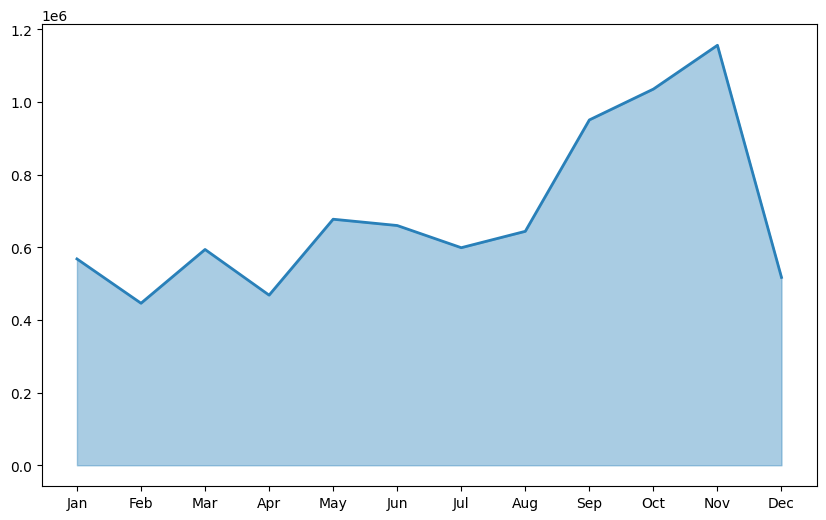

In [19]:
 # Lọc lấy dữ liệu của năm 2011 từ ngày 1/1 trở đi
df_filtered = df_clean[df_clean['InvoiceDate'] > '2010-12-31'] #thành dữ liệu năm mới nhất từ ngày 1/1 năm 2011 đến 9/12/2011

monthly_rev = df_filtered.groupby(df_filtered['InvoiceDate'].dt.strftime('%b'))['Revenue'].sum()

# Sắp xếp lại theo đúng thứ tự lịch (tránh bị xếp theo bảng chữ cái A-Z)
months_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_rev = monthly_rev.reindex(months_order).reset_index()

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))

# Vẽ vùng màu (Area)
plt.fill_between(monthly_rev['InvoiceDate'], monthly_rev['Revenue'], color=PRIMARY, alpha=0.4)

# Vẽ đường line phía trên
plt.plot(monthly_rev['InvoiceDate'], monthly_rev['Revenue'], color=PRIMARY, linewidth=2)

The business generates its primary sales from the UK market, with a significant seasonal peak during the year-end holiday season in November and December (data only 9 days)

III/ RFM ANALYSIS

In [20]:
# Identify the most recent date in your data
latest_date = df_clean['InvoiceDate'].max()

# Set reference date (1 day after the latest transaction)
REFERENCE_DATE = latest_date + dt.timedelta(days=1)


In [21]:
# Cal R, F, M
rfm = df_clean.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (REFERENCE_DATE - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('Revenue',     'sum')
).reset_index()

print(f"\n📊 RFM Summary:")
print(rfm[['Recency','Frequency','Monetary']].describe().round(2).to_string())



📊 RFM Summary:
       Recency  Frequency   Monetary
count  4338.00    4338.00    4338.00
mean     92.54       4.27    2048.69
std     100.01       7.70    8985.23
min       1.00       1.00       3.75
25%      18.00       1.00     306.48
50%      51.00       2.00     668.57
75%     142.00       5.00    1660.60
max     374.00     209.00  280206.02


In [22]:
# Recency: smaller = more recent = BETTER → reverse labels
rfm['R_Score'] = pd.qcut(rfm['Recency'].rank(method='first'), 5, labels=[5,4,3,2,1]).astype(int)

# Frequency & Monetary: larger = better → ascending labels
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

In [23]:
segment_dict = {
    'Champions': {'555','554','544','545','454','455','445'},
    'Loyal': {'543','444','435','355','354','345','344','335'},
    'Potential Loyalist': {'553','551','552','541','542','533','532','531','452','451','442',
                           '441','431','453','433','432','423','353','352','351','342','341','333','323'},
    'New Customers': {'512','511','422','421','412','411','311'},
    'Promising': {'525','524','523','522','521','515','514','513','425','424','413','414','415','315','314','313'},
    'Need Attention': {'535','534','443','434','343','334','325','324'},
    'About To Sleep': {'331','321','312','221','213','231','241','251'},
    'At Risk': {'255','254','245','244','253','252','243','242','235','234','225','224','153',
                '152','145','143','142','135','134','133','125','124'},
    'Cannot Lose Them': {'155','154','144','214','215','115','114','113'},
    'Hibernating Customers': {'332','322','233','232','223','222','132','123','122','212','211'},
    'Lost Customers': {'111','112','121','131','141','151'}
}

In [24]:
# Assign segments based on the mapping dictionary
def assign_segment(rfm_code):
    for segment, codes in segment_dict.items():
        if rfm_code in codes:
            return segment
    return 'Others'

# Apply to the dataframe
rfm['Segment'] = rfm['RFM_Score'].apply(assign_segment)

In [25]:
rfm

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346,326,1,77183.60,1,1,5,115,Cannot Lose Them
1,12347,2,7,4310.00,5,5,5,555,Champions
2,12348,75,4,1797.24,2,4,4,244,At Risk
3,12349,19,1,1757.55,4,1,4,414,Promising
4,12350,310,1,334.40,1,1,2,112,Lost Customers
...,...,...,...,...,...,...,...,...,...
4333,18280,278,1,180.60,1,2,1,121,Lost Customers
4334,18281,181,1,80.82,1,2,1,121,Lost Customers
4335,18282,8,2,178.05,5,3,1,531,Potential Loyalist
4336,18283,4,16,2045.53,5,5,4,554,Champions


In [26]:
seg_stats = (
    rfm.groupby('Segment')
    .agg(
        Cus       = ('CustomerID', 'count'),
        Avg_Recency = ('Recency',    'mean'),
        Avg_Freq    = ('Frequency',  'mean'),
        Avg_Mon     = ('Monetary',   'mean'),
        Total_Rev   = ('Monetary',   'sum'),
    )
    .reset_index()
    .sort_values('Cus', ascending=False)
    .reset_index(drop=True)
)

# %_Cus và %_Rev
seg_stats['%_Cus'] = (seg_stats['Cus'] / seg_stats['Cus'].sum()) * 100
seg_stats['%_Rev'] = (seg_stats['Total_Rev'] / seg_stats['Total_Rev'].sum()) * 100

cols = ['Segment','Cus','%_Cus','Avg_Recency','Avg_Freq','Avg_Mon','Total_Rev','%_Rev']
seg_stats = seg_stats[cols]

#Total
total_row = {
    'Segment': 'Total',
    'Cus': seg_stats['Cus'].sum(),
    '%_Cus': 100,
    'Avg_Recency': seg_stats['Avg_Recency'].mean(),
    'Avg_Freq': seg_stats['Avg_Freq'].mean(),
    'Avg_Mon': seg_stats['Avg_Mon'].mean(),
    'Total_Rev': seg_stats['Total_Rev'].sum(),
    '%_Rev': 100
}

#concat total
seg_stats_with_total = pd.concat([seg_stats, pd.DataFrame([total_row])], ignore_index=True)

print(f"Segment distribution: ")
print(seg_stats_with_total.round(2).to_string(index=False))

Segment distribution: 
              Segment  Cus  %_Cus  Avg_Recency  Avg_Freq  Avg_Mon  Total_Rev  %_Rev
            Champions  831  19.16        11.28     12.14  6716.97 5581802.32  62.81
Hibernating Customers  697  16.07       148.82      1.56   409.71  285570.76   3.21
       Lost Customers  489  11.27       274.80      1.07   199.37   97491.54   1.10
                Loyal  427   9.84        36.35      5.34  2389.32 1020240.32  11.48
              At Risk  425   9.80       143.17      3.76  1776.45  754990.25   8.50
   Potential Loyalist  405   9.34        26.30      2.52   538.55  218114.26   2.45
       Need Attention  286   6.59        33.29      3.12  1630.18  466230.62   5.25
       About To Sleep  285   6.57        86.06      1.28   275.95   78644.84   0.88
        New Customers  267   6.15        28.22      1.07   222.28   59347.96   0.67
            Promising  133   3.07        25.08      1.33   895.49  119099.52   1.34
     Cannot Lose Them   93   2.14       236.61      2

IV/ VISUALIZATION

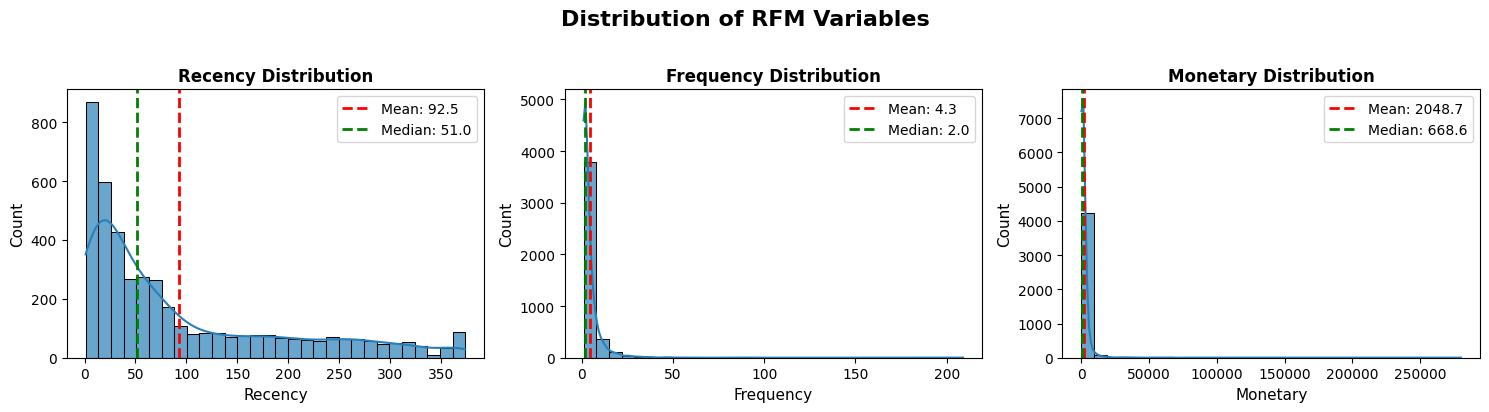

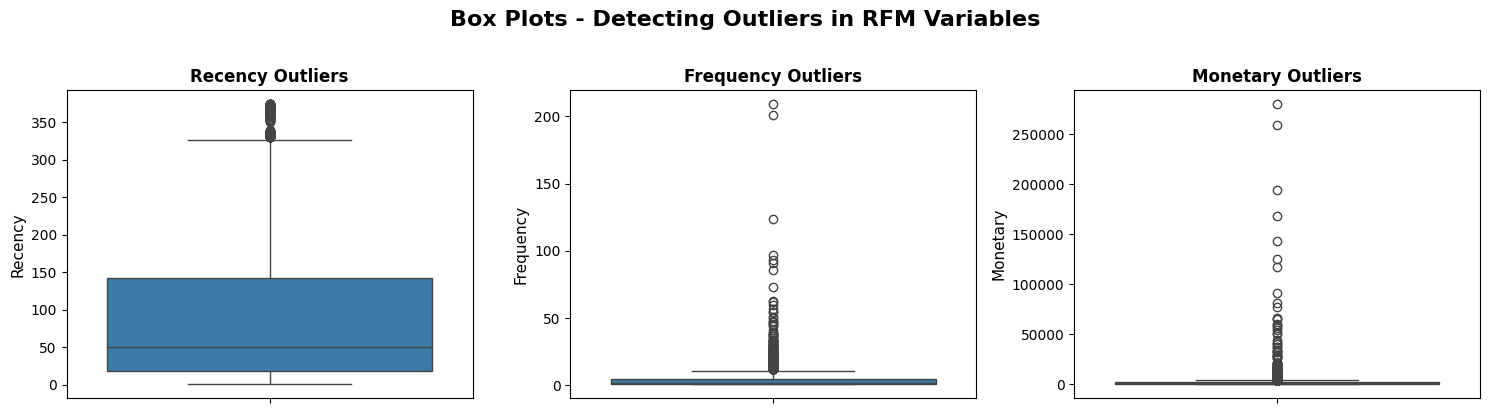

In [27]:
# Show distribution of each RFM variable
colnames = ['Recency', 'Frequency', 'Monetary']

fig, ax = plt.subplots(1,3,figsize=(15, 4))
fig.suptitle('Distribution of RFM Variables', fontsize=16, fontweight='bold', y=1.02)

for idx, col in enumerate(colnames):
    sns.histplot(rfm[col], kde=True, ax=ax[idx],color=PRIMARY, bins=30, alpha=0.7)
    ax[idx].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    ax[idx].set_xlabel(col, fontsize=11)
    ax[idx].set_ylabel('Count', fontsize=11)

    mean_val = rfm[col].mean()
    median_val = rfm[col].median()
    ax[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
    ax[idx].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.1f}')
    ax[idx].legend()

plt.tight_layout()
plt.show()

# Box plots to show outliers
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Box Plots - Detecting Outliers in RFM Variables', fontsize=16, fontweight='bold', y=1.02)

for idx, col in enumerate(colnames):
    sns.boxplot(y=rfm[col], ax=ax[idx], color=PRIMARY)
    ax[idx].set_title(f'{col} Outliers', fontsize=12, fontweight='bold')
    ax[idx].set_ylabel(col, fontsize=11)

plt.tight_layout()
plt.show()


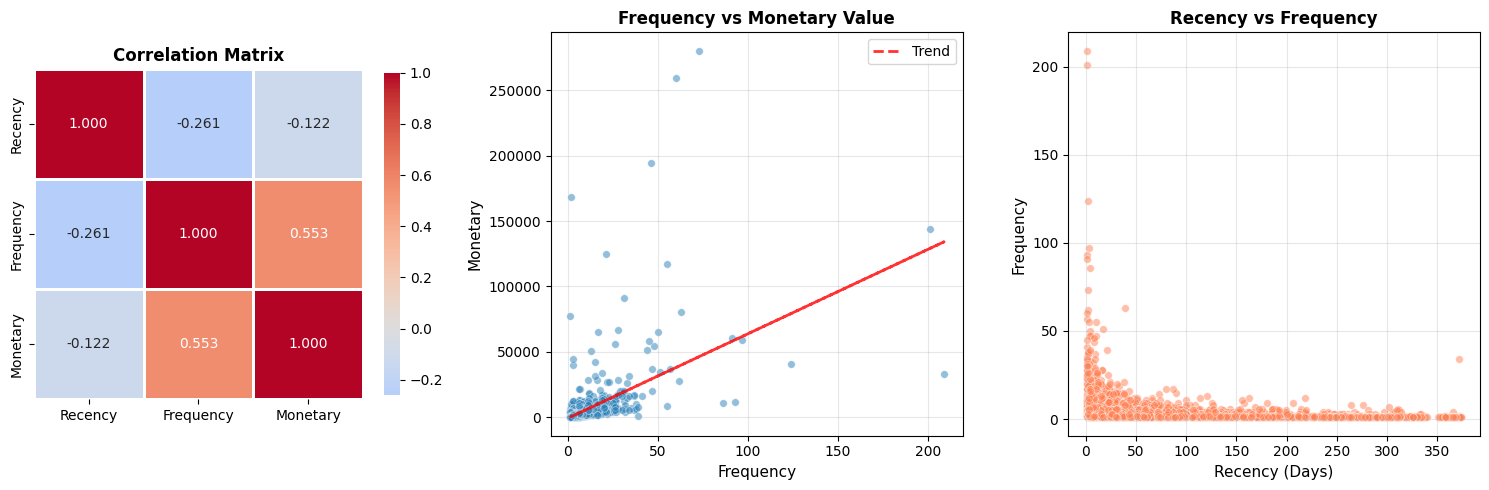

In [28]:
# 2. CORRELATION ANALYSIS - Relationships Between Variables
# ============================================================================
fig = plt.figure(figsize=(15, 5))

# 2A. Correlation Heatmap
ax1 = plt.subplot(1, 3, 1)
correlation_matrix = rfm[colnames].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=2, cbar_kws={"shrink": 0.8}, ax=ax1)
ax1.set_title('Correlation Matrix', fontsize=12, fontweight='bold')

# 2B. Frequency vs Monetary Scatter
ax2 = plt.subplot(1, 3, 2)
ax2.scatter(rfm['Frequency'], rfm['Monetary'], alpha=0.5, s=30,  c=PRIMARY, edgecolors='white', linewidth=0.5)
ax2.set_xlabel('Frequency', fontsize=11)
ax2.set_ylabel('Monetary', fontsize=11)
ax2.set_title('Frequency vs Monetary Value', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Add regression line
z = np.polyfit(rfm['Frequency'], rfm['Monetary'], 1)
p = np.poly1d(z)
ax2.plot(rfm['Frequency'], p(rfm['Frequency']), "r--", alpha=0.8, linewidth=2, label='Trend')
ax2.legend()

# 2C. Recency vs Frequency Scatter
ax3 = plt.subplot(1, 3, 3)
ax3.scatter(rfm['Recency'], rfm['Frequency'], alpha=0.5, s=30, c='coral', edgecolors='white', linewidth=0.5)
ax3.set_xlabel('Recency (Days)', fontsize=11)
ax3.set_ylabel('Frequency', fontsize=11)
ax3.set_title('Recency vs Frequency', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [29]:
# Segment Characteristics Heatmap
segment_rfm = rfm.groupby('Segment')[colnames].mean().round(2)

colscore = ['R_Score', 'F_Score', 'M_Score']
segment_rfm_score = rfm.groupby('Segment')[colscore].mean().round(2)

from IPython.display import display_html

# 1. Chuẩn bị dữ liệu: Đưa Segment từ Index vào thành 1 cột bình thường
df_score = segment_rfm_score.reset_index()
df_actual = segment_rfm.reset_index()

# 2. Định nghĩa CSS để tùy chỉnh độ rộng từng cột
# Cột đầu tiên (Segment) là index 0 -> rộng 200px. Các cột sau rộng 100px.
common_styles = [
    {'selector': 'th, td', 'props': [('height', '40px'), ('text-align', 'center'), ('border', '1px solid white')]},
    {'selector': 'td:nth-child(1), th:nth-child(1)', 'props': [('width', '180px'), ('text-align', 'left'), ('padding-left', '10px')]}, # Cột Segment
    {'selector': 'td:not(:nth-child(1)), th:not(:nth-child(1))', 'props': [('width', '80px')]} # Các cột số
]

# 3. Tạo Styler (ẩn Index mặc định của Pandas bằng .hide())
styler_score = df_score.style.set_table_styles(common_styles).hide(axis='index').background_gradient(
    cmap='RdYlGn', subset=colscore
).format("{:.2f}", subset=colscore).set_caption("<b>RFM Scores</b>")

styler_actual = df_actual.style.set_table_styles(common_styles).hide(axis='index').background_gradient(
    cmap='RdYlGn_r', subset=['Recency']
).background_gradient(
    cmap='RdYlGn', subset=['Frequency', 'Monetary']
).format("{:,.2f}", subset=['Frequency', 'Monetary']).format("{:.2f}", subset=['Recency']).set_caption("<b>Actual RFM Values</b>")

# 4. Hiển thị song song
display_html(f"""
    <div style="display: flex; gap: 100px; align-items: flex-start;">
        <div>{styler_actual._repr_html_()}</div>
        <div>{styler_score._repr_html_()}</div>
    </div>
""", raw=True)


Segment,Recency,Frequency,Monetary
About To Sleep,86.06,1.28,275.95
At Risk,143.17,3.76,"1,776.45"
Cannot Lose Them,236.61,2.34,"2,211.58"
Champions,11.28,12.14,"6,716.97"
Hibernating Customers,148.82,1.56,409.71
Lost Customers,274.80,1.07,199.37
Loyal,36.35,5.34,"2,389.32"
Need Attention,33.29,3.12,"1,630.18"
New Customers,28.22,1.07,222.28
Potential Loyalist,26.30,2.52,538.55


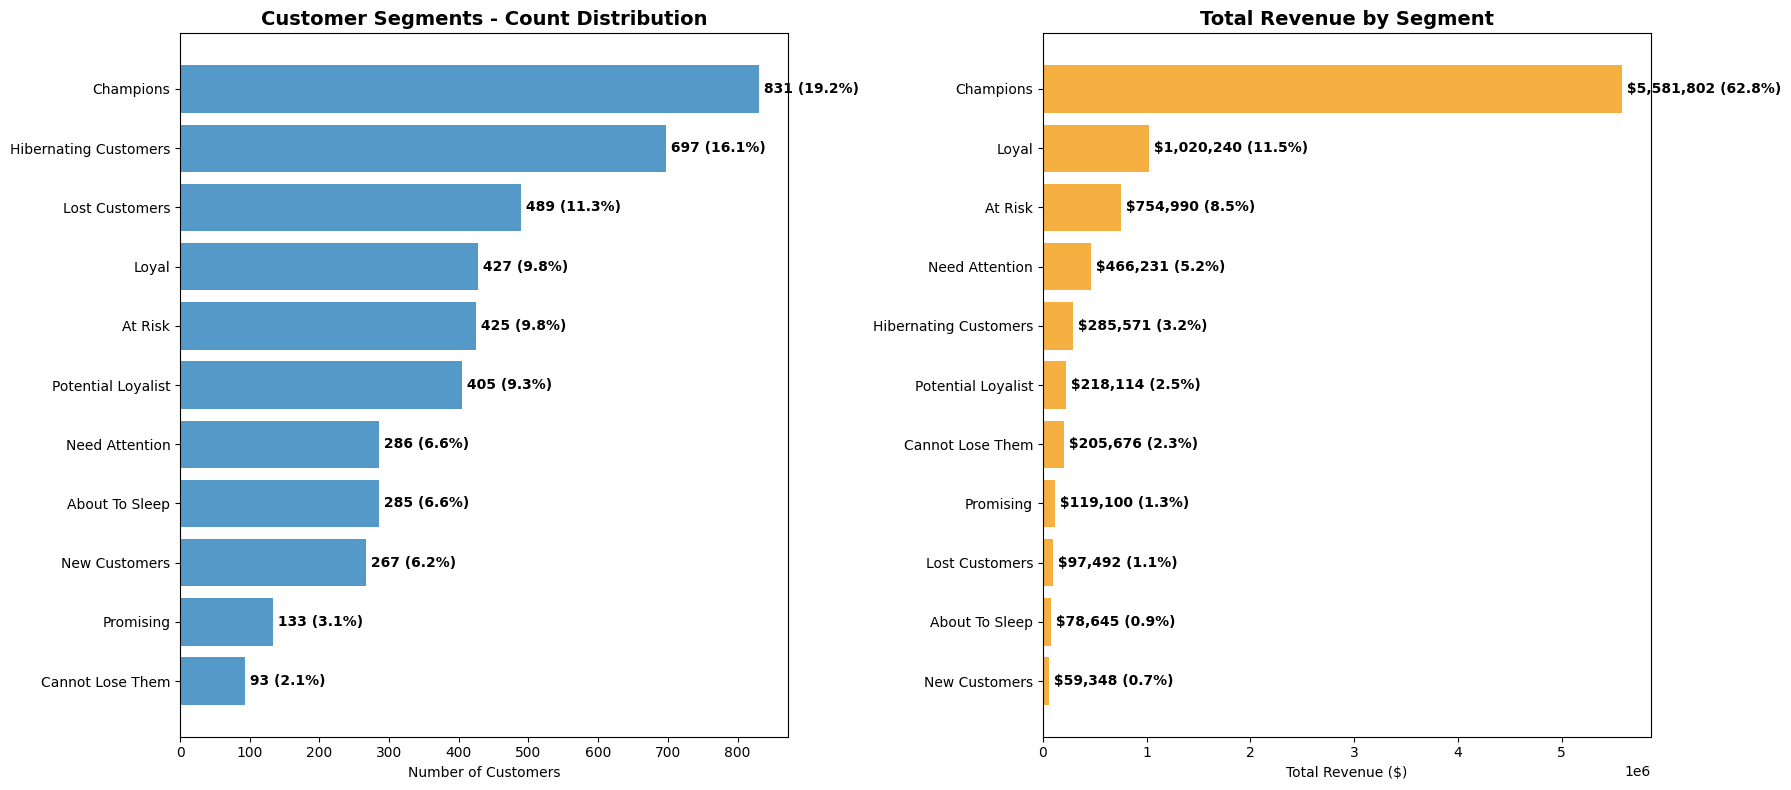

In [30]:
if 'Segment' in rfm.columns:

    # Chuẩn bị dữ liệu 1
    segment_counts = rfm['Segment'].value_counts().reset_index()
    segment_counts.columns = ['Segment', 'Count']
    segment_counts['Percentage'] = (segment_counts['Count'] / segment_counts['Count'].sum() * 100).round(2)
    segment_counts = segment_counts.sort_values('Count', ascending=True) # Để thằng cao nhất nằm trên cùng khi vẽ barh

    # Chuẩn bị dữ liệu 2
    segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=True)
    segment_revenue_pct = (segment_revenue / segment_revenue.sum() * 100).round(2)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

    # --- BIỂU ĐỒ 1: Số lượng khách hàng ---
    bars1 = ax1.barh(segment_counts['Segment'], segment_counts['Count'], color = PRIMARY, alpha=0.8)
    ax1.set_title('Customer Segments - Count Distribution', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Number of Customers')

    # Ghi chú số liệu trên đầu cột ngang
    for bar, count, pct in zip(bars1, segment_counts['Count'], segment_counts['Percentage']):
        width = bar.get_width()
        ax1.text(width, bar.get_y() + bar.get_height()/2,
                 f' {int(count)} ({pct:.1f}%)',
                 va='center', fontsize=10, fontweight='bold')

    # --- BIỂU ĐỒ 2: Doanh thu ---
    bars2 = ax2.barh(segment_revenue.index, segment_revenue.values, color = SECONDARY, alpha=0.8)
    ax2.set_title('Total Revenue by Segment', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Total Revenue ($)')

    # Ghi chú số liệu trên đầu cột ngang
    for bar, rev, pct in zip(bars2, segment_revenue.values, segment_revenue_pct.values):
        width = bar.get_width()
        ax2.text(width, bar.get_y() + bar.get_height()/2,
                 f' ${rev:,.0f} ({pct:.1f}%)',
                 va='center', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

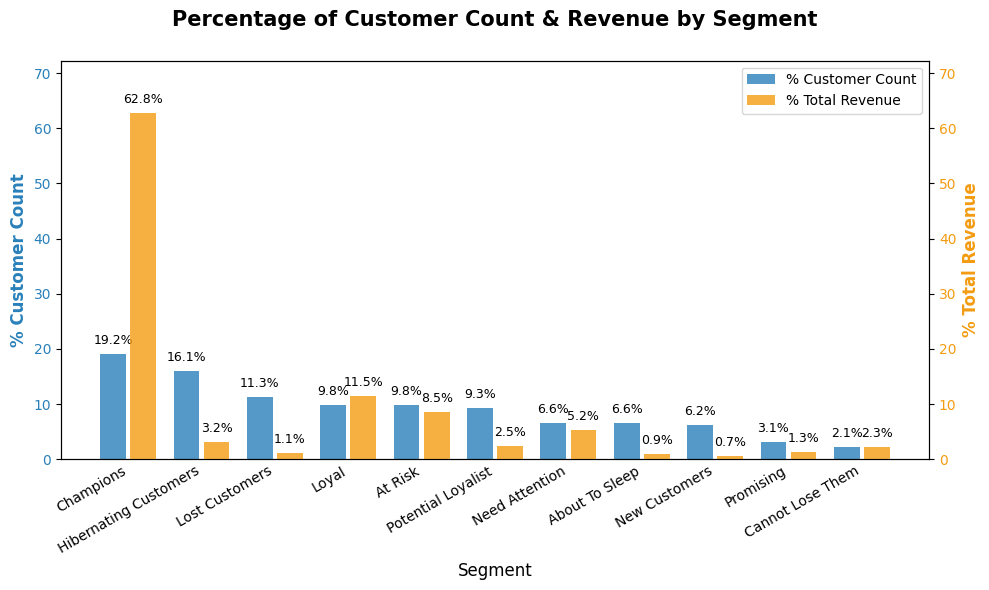

In [31]:
if 'Segment' in rfm.columns:
    # 1. Chuẩn bị dữ liệu tổng hợp
    summary = rfm.groupby('Segment').agg(
        Count=('Segment', 'count'),
        Revenue=('Monetary', 'sum')
    ).sort_values('Count', ascending=False)

    # Tính toán tỷ lệ phần trăm trực tiếp
    summary['Pct_Count'] = (summary['Count'] / summary['Count'].sum() * 100)
    summary['Pct_Rev'] = (summary['Revenue'] / summary['Revenue'].sum() * 100)

    # 2. Vẽ biểu đồ dựa trên giá trị %
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax2 = ax1.twinx()

    x = np.arange(len(summary))

    width = 0.35
    offset = 0.03    # Khoảng cách nhỏ giữa 2 cột xanh - vàng

    # Vẽ cột bằng dữ liệu %
    bars1 = ax1.bar(x - width/2 - offset, summary['Pct_Count'], width, label='% Customer Count', color=PRIMARY, alpha=0.8)
    bars2 = ax2.bar(x + width/2 + offset, summary['Pct_Rev'], width, label='% Total Revenue', color=SECONDARY, alpha=0.8)

    # 3. Hàm thêm label (Chỉ hiển thị %)
    def add_labels(bars, ax):
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 5),
                        textcoords="offset points",
                        ha='center', va='bottom',
                        fontsize=9)

    add_labels(bars1, ax1)
    add_labels(bars2, ax2)

    # 4. Định dạng trục và tiêu đề
    ax1.set_xlabel('Segment', fontsize=12)
    ax1.set_ylabel('% Customer Count', fontsize=12, color=PRIMARY, fontweight='bold')
    ax2.set_ylabel('% Total Revenue', fontsize=12, color=SECONDARY, fontweight='bold')
    ax1.set_title('Percentage of Customer Count & Revenue by Segment', fontsize=15, fontweight='bold', pad=25)

    # Giới hạn trục Y từ 0-100% (hoặc tùy chỉnh dựa trên max value để biểu đồ thoáng hơn)
    max_val = max(summary['Pct_Count'].max(), summary['Pct_Rev'].max())
    ax1.set_ylim(0, max_val * 1.15)
    ax2.set_ylim(0, max_val * 1.15)

    ax1.set_xticks(x)
    ax1.set_xticklabels(summary.index, rotation=30, ha='right')
    ax1.tick_params(axis='x', which='both', length=0) # Bỏ dấu gạch nhỏ
    ax1.tick_params(axis='y', labelcolor=PRIMARY)
    ax2.tick_params(axis='y', labelcolor=SECONDARY)

    # Legend
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc='upper right')

    plt.tight_layout()
    plt.show()

